<a href="https://colab.research.google.com/github/Mohinish-K053/BDA/blob/main/BDA_colabfile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 Iris Dataset loaded: 150 samples, 5 features

 Descriptive Statistics (Sepal Length):
       sepal_length
count       150.000
mean          5.843
std           0.828
min           4.300
25%           5.100
50%           5.800
75%           6.400
max           7.900
  Skewness : 0.3149
  Kurtosis : -0.5521


/tmp/ipykernel_28106/3101889926.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(species_data, vert=True, patch_artist=True,


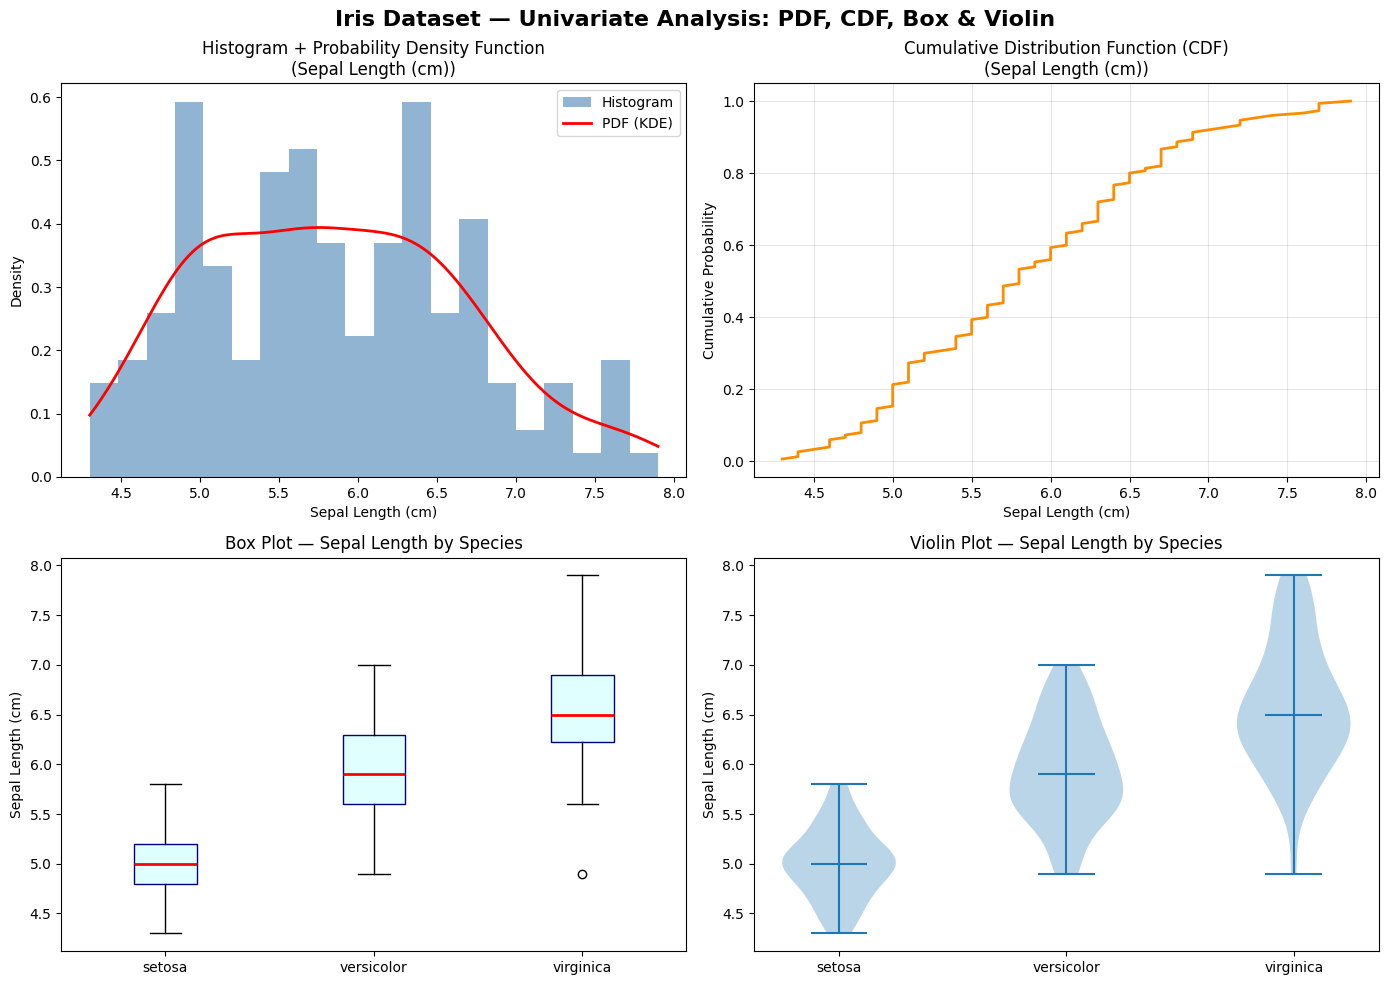

In [1]:
!pip install numpy pandas matplotlib scipy seaborn scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris


iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width',
                                       'petal_length', 'petal_width'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

data = df['sepal_length'].values
feature_name = 'Sepal Length (cm)'

print(f"\n Iris Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

print("\n Descriptive Statistics (Sepal Length):")
print(df[['sepal_length']].describe().round(3))
print(f"  Skewness : {df['sepal_length'].skew():.4f}")
print(f"  Kurtosis : {df['sepal_length'].kurt():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset — Univariate Analysis: PDF, CDF, Box & Violin', fontsize=16, fontweight='bold')

ax = axes[0, 0]
ax.hist(data, bins=20, density=True, alpha=0.6, color='steelblue', label='Histogram')
kde = stats.gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 300)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='PDF (KDE)')
ax.set_title(f'Histogram + Probability Density Function\n({feature_name})')
ax.set_xlabel(feature_name); ax.set_ylabel('Density')
ax.legend()

ax = axes[0, 1]
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
ax.plot(sorted_data, cdf, color='darkorange', linewidth=2)
ax.set_title(f'Cumulative Distribution Function (CDF)\n({feature_name})')
ax.set_xlabel(feature_name); ax.set_ylabel('Cumulative Probability')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
species_data = [df[df['species'] == sp]['sepal_length'].values for sp in iris.target_names]
bp = ax.boxplot(species_data, vert=True, patch_artist=True,
                labels=iris.target_names,
                boxprops=dict(facecolor='lightcyan', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot — Sepal Length by Species')
ax.set_ylabel(feature_name)

ax = axes[1, 1]
ax.violinplot(species_data, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(iris.target_names)
ax.set_title('Violin Plot — Sepal Length by Species')
ax.set_ylabel(feature_name)

plt.tight_layout()
plt.savefig('assignment1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

📦 Iris Dataset loaded: (150, 6)
  Mean=5.843 cm, Std=0.828 cm
  P(sepal_length > 6.5)          = 0.2139  (21.39%)
  P(sepal_length < 5.0)          = 0.1542  (15.42%)
  P(5.0 < sepal_length < 6.5)    = 0.6319  (63.19%)
  Shapiro-Wilk test: stat=0.9761, p=0.0102
  Normal? No (p < 0.05)
  Lambda (expected count) = 5
  P(exactly 3 samples)    = 0.1404
  P(more than 7 samples)  = 0.1334


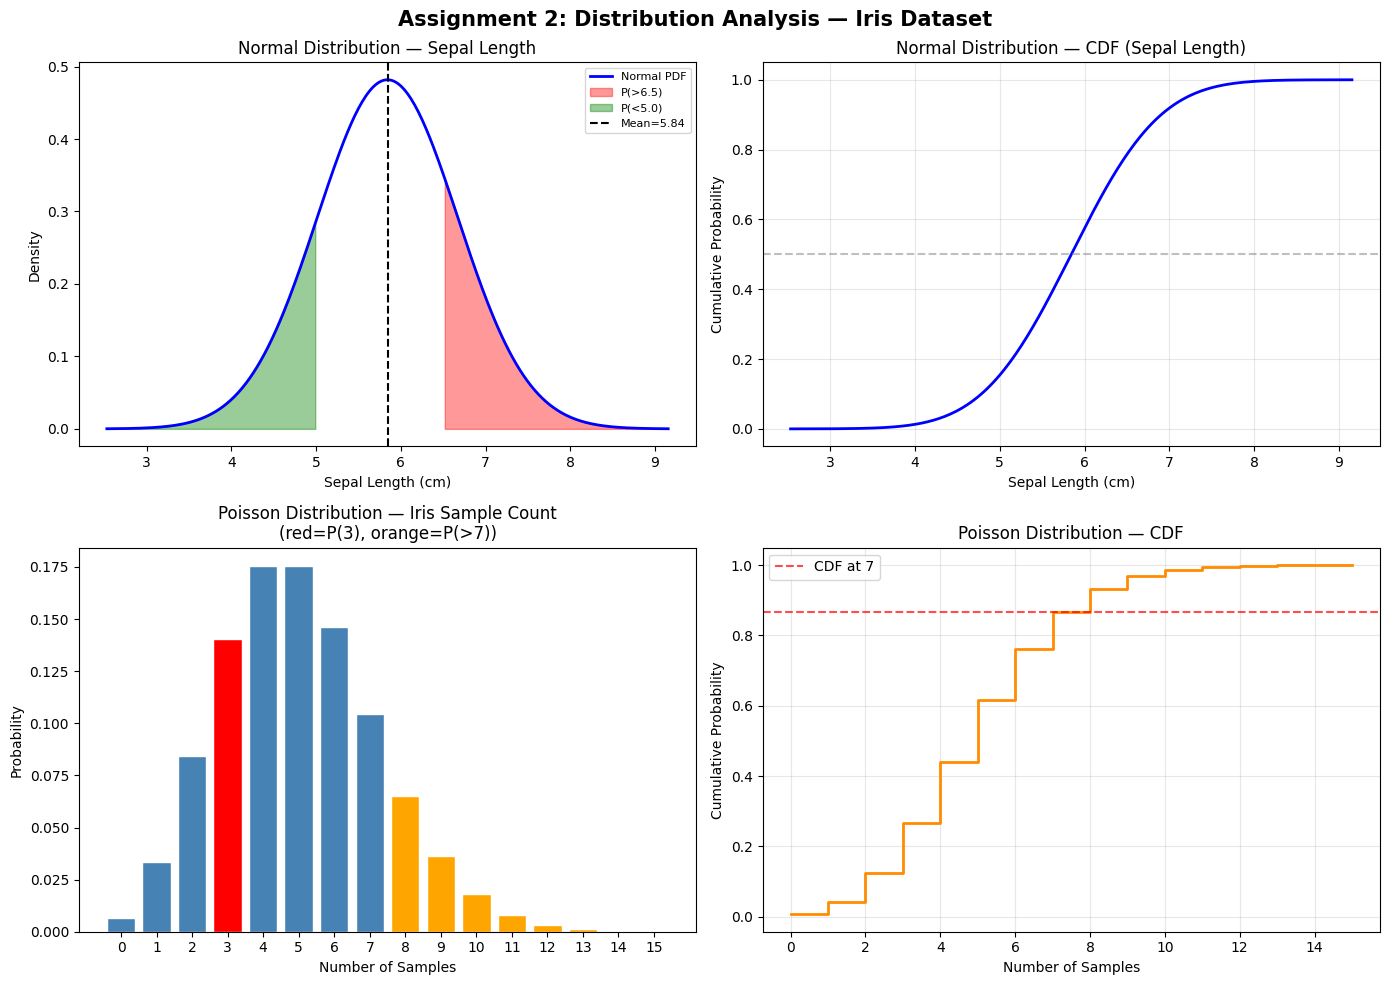

In [2]:

!pip install numpy pandas matplotlib scipy scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_iris


iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width',
                                       'petal_length', 'petal_width'])
df['species_id'] = iris.target
df['species']    = pd.Categorical.from_codes(iris.target, iris.target_names)
print(f"📦 Iris Dataset loaded: {df.shape}")


sl = df['sepal_length']
mu, sigma = sl.mean(), sl.std()
dist_norm = stats.norm(mu, sigma)

p_above_65 = 1 - dist_norm.cdf(6.5)
p_below_50 = dist_norm.cdf(5.0)
p_between  = dist_norm.cdf(6.5) - dist_norm.cdf(5.0)

print(f"  Mean={mu:.3f} cm, Std={sigma:.3f} cm")
print(f"  P(sepal_length > 6.5)          = {p_above_65:.4f}  ({p_above_65*100:.2f}%)")
print(f"  P(sepal_length < 5.0)          = {p_below_50:.4f}  ({p_below_50*100:.2f}%)")
print(f"  P(5.0 < sepal_length < 6.5)    = {p_between:.4f}  ({p_between*100:.2f}%)")

stat_sw, p_sw = stats.shapiro(sl)
print(f"  Shapiro-Wilk test: stat={stat_sw:.4f}, p={p_sw:.4f}")
print(f"  Normal? {'Yes' if p_sw > 0.05 else 'No (p < 0.05)'}")


lam = 5
dist_poisson = stats.poisson(lam)

p_exactly_3 = dist_poisson.pmf(3)
p_more_than_7 = 1 - dist_poisson.cdf(7)

print(f"  Lambda (expected count) = {lam}")
print(f"  P(exactly 3 samples)    = {p_exactly_3:.4f}")
print(f"  P(more than 7 samples)  = {p_more_than_7:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Assignment 2: Distribution Analysis — Iris Dataset', fontsize=15, fontweight='bold')

ax = axes[0, 0]
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, dist_norm.pdf(x), 'b-', linewidth=2, label='Normal PDF')
ax.fill_between(x, dist_norm.pdf(x), where=(x > 6.5), alpha=0.4, color='red',   label='P(>6.5)')
ax.fill_between(x, dist_norm.pdf(x), where=(x < 5.0), alpha=0.4, color='green', label='P(<5.0)')
ax.axvline(mu, color='black', linestyle='--', label=f'Mean={mu:.2f}')
ax.set_title('Normal Distribution — Sepal Length')
ax.set_xlabel('Sepal Length (cm)'); ax.set_ylabel('Density')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(x, dist_norm.cdf(x), 'b-', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Normal Distribution — CDF (Sepal Length)')
ax.set_xlabel('Sepal Length (cm)'); ax.set_ylabel('Cumulative Probability')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
k_vals = np.arange(0, 16)
pmf_vals = dist_poisson.pmf(k_vals)
colors = ['red' if k == 3 else ('orange' if k > 7 else 'steelblue') for k in k_vals]
ax.bar(k_vals, pmf_vals, color=colors, edgecolor='white')
ax.set_title('Poisson Distribution — Iris Sample Count\n(red=P(3), orange=P(>7))')
ax.set_xlabel('Number of Samples'); ax.set_ylabel('Probability')
ax.set_xticks(k_vals)

ax = axes[1, 1]
cdf_vals = dist_poisson.cdf(k_vals)
ax.step(k_vals, cdf_vals, where='post', color='darkorange', linewidth=2)
ax.axhline(1 - p_more_than_7, color='red', linestyle='--', alpha=0.7, label='CDF at 7')
ax.set_title('Poisson Distribution — CDF')
ax.set_xlabel('Number of Samples'); ax.set_ylabel('Cumulative Probability')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assignment2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

📦 Iris Dataset: (150, 6)
  Sample mean: 5.8433 cm

  Test      : One-Sample t-test
  Statistic : 0.6409
  p-value   : 0.5226
  Decision  : ❌ Fail to Reject H0  (α = 0.05)
  Mean Setosa: 5.0060  |  Mean Versicolor: 5.9360

  Test      : Independent t-test
  Statistic : -10.5210
  p-value   : 0.0000
  Decision  : ✅ Reject H0  (α = 0.05)
  Sample mean: 3.7580 cm  |  n = 150

  Test      : Z-test (one-tailed)
  Statistic : 0.4024
  p-value   : 0.3437
  Decision  : ❌ Fail to Reject H0  (α = 0.05)
  Observed table:
[[50  0]
 [ 7 43]
 [ 0 50]]
  Degrees of Freedom: 2

  Test      : Chi-Square
  Statistic : 124.4482
  p-value   : 0.0000
  Decision  : ✅ Reject H0  (α = 0.05)
  Means — Setosa:1.462  Versicolor:4.260  Virginica:5.552

  Test      : One-Way ANOVA (F-test)
  Statistic : 1180.1612
  p-value   : 0.0000
  Decision  : ✅ Reject H0  (α = 0.05)


/tmp/ipykernel_28106/2858961176.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([setosa, versicolor], labels=['Setosa', 'Versicolor'], patch_artist=True,
/tmp/ipykernel_28106/2858961176.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([grp_setosa, grp_versicolor, grp_virginica],


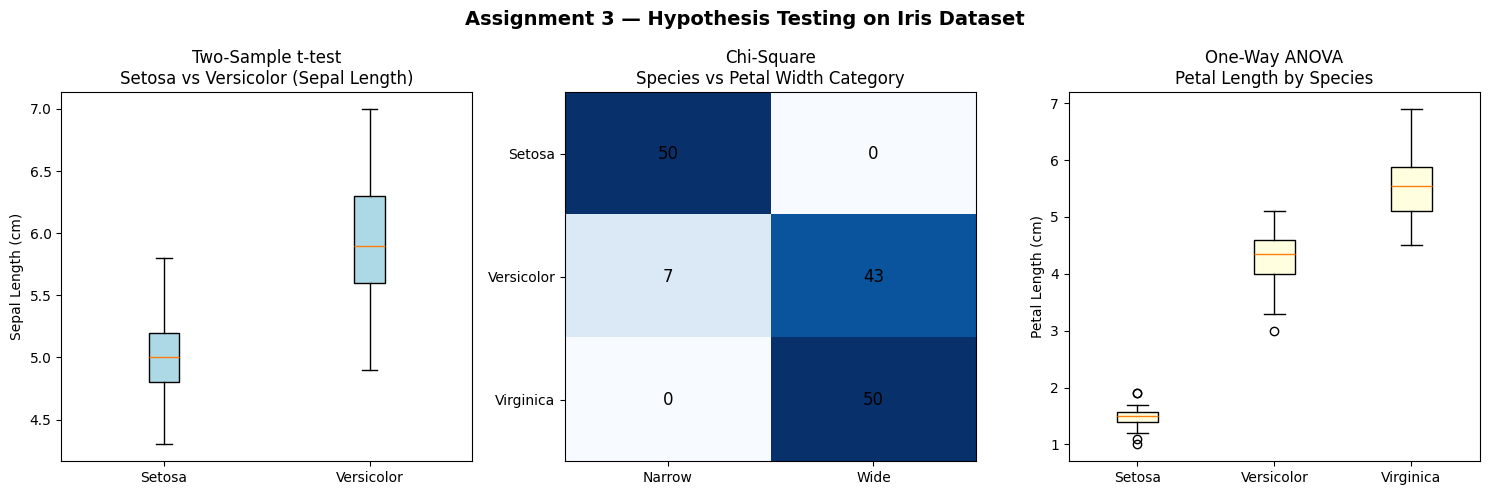

In [3]:
!pip install numpy pandas scipy statsmodels matplotlib scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.weightstats import ztest
from sklearn.datasets import load_iris


iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width',
                                       'petal_length', 'petal_width'])
df['species_id'] = iris.target
df['species']    = pd.Categorical.from_codes(iris.target, iris.target_names)
print(f"📦 Iris Dataset: {df.shape}")

ALPHA = 0.05

def print_result(test_name, stat, p_val, alpha=ALPHA):
    print(f"\n  Test      : {test_name}")
    print(f"  Statistic : {stat:.4f}")
    print(f"  p-value   : {p_val:.4f}")
    decision = "✅ Reject H0" if p_val < alpha else "❌ Fail to Reject H0"
    print(f"  Decision  : {decision}  (α = {alpha})")

sepal_len = df['sepal_length'].values
t_stat, p_val = stats.ttest_1samp(sepal_len, popmean=5.8)
print(f"  Sample mean: {sepal_len.mean():.4f} cm")
print_result("One-Sample t-test", t_stat, p_val)


setosa     = df[df['species'] == 'setosa']['sepal_length'].values
versicolor = df[df['species'] == 'versicolor']['sepal_length'].values
t_stat, p_val = stats.ttest_ind(setosa, versicolor)
print(f"  Mean Setosa: {setosa.mean():.4f}  |  Mean Versicolor: {versicolor.mean():.4f}")
print_result("Independent t-test", t_stat, p_val)


petal_len = df['petal_length'].values
z_stat, p_val = ztest(petal_len, value=3.7, alternative='larger')
print(f"  Sample mean: {petal_len.mean():.4f} cm  |  n = {len(petal_len)}")
print_result("Z-test (one-tailed)", z_stat, p_val)


df['petal_wide'] = pd.cut(df['petal_width'], bins=[0, 1.0, 2.5],
                           labels=['narrow', 'wide'])
contingency = pd.crosstab(df['species'], df['petal_wide']).values
print(f"  Observed table:\n{contingency}")
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"  Degrees of Freedom: {dof}")
print_result("Chi-Square", chi2, p_val)


grp_setosa     = df[df['species'] == 'setosa']['petal_length'].values
grp_versicolor = df[df['species'] == 'versicolor']['petal_length'].values
grp_virginica  = df[df['species'] == 'virginica']['petal_length'].values
f_stat, p_val = stats.f_oneway(grp_setosa, grp_versicolor, grp_virginica)
print(f"  Means — Setosa:{grp_setosa.mean():.3f}  Versicolor:{grp_versicolor.mean():.3f}  Virginica:{grp_virginica.mean():.3f}")
print_result("One-Way ANOVA (F-test)", f_stat, p_val)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Assignment 3 — Hypothesis Testing on Iris Dataset', fontsize=14, fontweight='bold')


axes[0].boxplot([setosa, versicolor], labels=['Setosa', 'Versicolor'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Two-Sample t-test\nSetosa vs Versicolor (Sepal Length)')
axes[0].set_ylabel('Sepal Length (cm)')


axes[1].imshow(contingency, cmap='Blues', aspect='auto')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Narrow', 'Wide'])
axes[1].set_yticks([0, 1, 2]); axes[1].set_yticklabels(['Setosa', 'Versicolor', 'Virginica'])
axes[1].set_title('Chi-Square\nSpecies vs Petal Width Category')
for i in range(3):
    for j in range(2):
        axes[1].text(j, i, contingency[i, j], ha='center', va='center', fontsize=12)


axes[2].boxplot([grp_setosa, grp_versicolor, grp_virginica],
                labels=['Setosa', 'Versicolor', 'Virginica'],
                patch_artist=True, boxprops=dict(facecolor='lightyellow'))
axes[2].set_title('One-Way ANOVA\nPetal Length by Species')
axes[2].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.savefig('assignment3_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()


🔹 Shape: (150, 6)

🔹 First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width  species_id species
0           5.1          3.5           1.4          0.2           0  setosa
1           4.9          3.0           1.4          0.2           0  setosa
2           4.7          3.2           1.3          0.2           0  setosa
3           4.6          3.1           1.5          0.2           0  setosa
4           5.0          3.6           1.4          0.2           0  setosa

🔹 Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_id      0
species         0
dtype: int64

🔹 Descriptive stats:
        sepal_length  sepal_width  petal_length  petal_width  species_id
count       150.000      150.000       150.000      150.000     150.000
mean          5.843        3.057         3.758        1.199       1.000
std           0.828        0.436         1.765        0.762       0.819
min           4.300        2.000         1.000        0

/tmp/ipykernel_28106/1167699058.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal_length', ax=axes[0], palette='Set2')


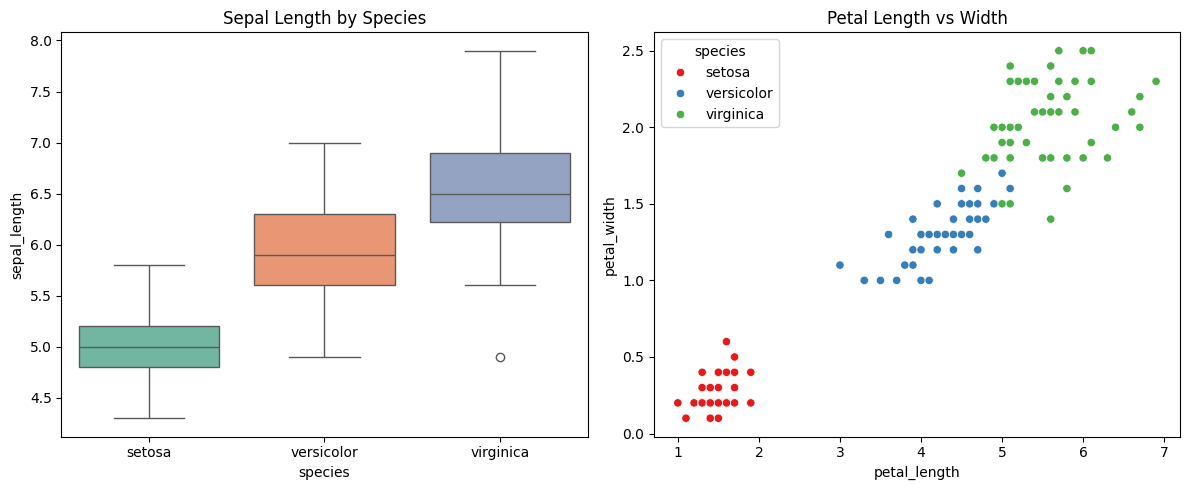

✅ SparkSession created


/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/dataframe.py:178: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)



🔹 Schema:
root
 |-- book_id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- author: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- year: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- copies_sold: long (nullable = true)


🔹 All Books:
+-------+----------------------+-------------------+-----------+----+------+-----------+
|book_id|title                 |author             |genre      |year|rating|copies_sold|
+-------+----------------------+-------------------+-----------+----+------+-----------+
|1      |The Great Gatsby      |F. Scott Fitzgerald|Fiction    |1925|4.1   |500000     |
|2      |To Kill a Mockingbird |Harper Lee         |Fiction    |1960|4.3   |750000     |
|3      |1984                  |George Orwell      |Dystopian  |1949|4.5   |800000     |
|4      |Pride and Prejudice   |Jane Austen        |Romance    |1813|4.2   |600000     |
|5      |The Catcher in the Rye|J.D. Salinger      |Fiction    |1951|3.8   |400000  

In [5]:
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark pandas numpy matplotlib seaborn --quiet
!apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, desc, upper, length


iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length','sepal_width',
                                       'petal_length','petal_width'])
df['species_id']  = iris.target
df['species']     = df['species_id'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

print("\n🔹 Shape:", df.shape)
print("\n🔹 First 5 rows:\n", df.head())
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Descriptive stats:\n", df.describe().round(3))

print("\n🔹 Mean per species:")
print(df.groupby('species')[['sepal_length','petal_length']].mean().round(3))

filtered = df[df['sepal_length'] > 6.0]
print(f"\n🔹 Rows with sepal_length > 6.0: {len(filtered)}")

df['petal_ratio'] = (df['petal_length'] / df['petal_width']).round(3)
print("\n🔹 Petal ratio (first 5):\n", df[['species','petal_ratio']].head())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='sepal_length', ax=axes[0], palette='Set2')
axes[0].set_title('Sepal Length by Species')
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', ax=axes[1], palette='Set1')
axes[1].set_title('Petal Length vs Width')
plt.tight_layout()
plt.savefig('assignment4_iris_wrangling.png', dpi=150, bbox_inches='tight')
plt.show()


spark = SparkSession.builder \
    .appName("BookDatasetAnalysis") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("✅ SparkSession created")

book_data = [
    (1, "The Great Gatsby",         "F. Scott Fitzgerald", "Fiction",    1925, 4.1, 500000),
    (2, "To Kill a Mockingbird",    "Harper Lee",          "Fiction",    1960, 4.3, 750000),
    (3, "1984",                     "George Orwell",       "Dystopian",  1949, 4.5, 800000),
    (4, "Pride and Prejudice",      "Jane Austen",         "Romance",    1813, 4.2, 600000),
    (5, "The Catcher in the Rye",   "J.D. Salinger",       "Fiction",    1951, 3.8, 400000),
    (6, "Brave New World",          "Aldous Huxley",       "Dystopian",  1932, 4.0, 350000),
    (7, "The Hobbit",               "J.R.R. Tolkien",      "Fantasy",    1937, 4.6, 900000),
    (8, "Harry Potter",             "J.K. Rowling",        "Fantasy",    1997, 4.8, 1200000),
    (9, "The Da Vinci Code",        "Dan Brown",           "Thriller",   2003, 3.7, 450000),
    (10,"Sapiens",                  "Yuval Noah Harari",   "Non-Fiction",2011, 4.4, 650000),
]
schema = ["book_id","title","author","genre","year","rating","copies_sold"]
books_df = spark.createDataFrame(book_data, schema=schema)

books_df.registerTempTable("books")
print("\n🔹 Schema:"); books_df.printSchema()
print("\n🔹 All Books:"); books_df.show(truncate=False)

print("🔹 SQL — Top 5 Rated Books:")
spark.sql("""
    SELECT title, author, rating
    FROM books
    ORDER BY rating DESC
    LIMIT 5
""").show(truncate=False)

print("🔹 SQL — Average Rating per Genre:")
spark.sql("""
    SELECT genre,
           COUNT(*) as book_count,
           ROUND(AVG(rating), 2) as avg_rating,
           SUM(copies_sold) as total_copies
    FROM books
    GROUP BY genre
    ORDER BY avg_rating DESC
""").show()

print("🔹 SQL — Books Published After 1950:")
spark.sql("SELECT title, year, genre FROM books WHERE year > 1950 ORDER BY year").show(truncate=False)

# DataFrame API — filter + transform
print("🔹 DataFrame API — Fantasy/Dystopian books with rating > 4.0:")
books_df.filter(
    (col("genre").isin("Fantasy","Dystopian")) & (col("rating") > 4.0)
).select("title","genre","rating","copies_sold").show(truncate=False)

spark.stop()

📦 Iris Dataset loaded: (150, 5)

🔹 Dataset shape: (150, 5)

🔹 Descriptive Stats:
        sepal_length  sepal_width  petal_length  petal_width  species_id
count       150.000      150.000       150.000      150.000     150.000
mean          5.843        3.057         3.758        1.199       1.000
std           0.828        0.436         1.765        0.762       0.819
min           4.300        2.000         1.000        0.100       0.000
25%           5.100        2.800         1.600        0.300       0.000
50%           5.800        3.000         4.350        1.300       1.000
75%           6.400        3.300         5.100        1.800       2.000
max           7.900        4.400         6.900        2.500       2.000

🔹 Correlation with petal_length:
 petal_length    1.000
petal_width     0.963
species_id      0.949
sepal_length    0.872
sepal_width    -0.428
Name: petal_length, dtype: float64

📊 Model Performance:
  MAE  = 0.2471
  MSE  = 0.1199
  RMSE = 0.3462
  R²   = 0.9634

🔹 C

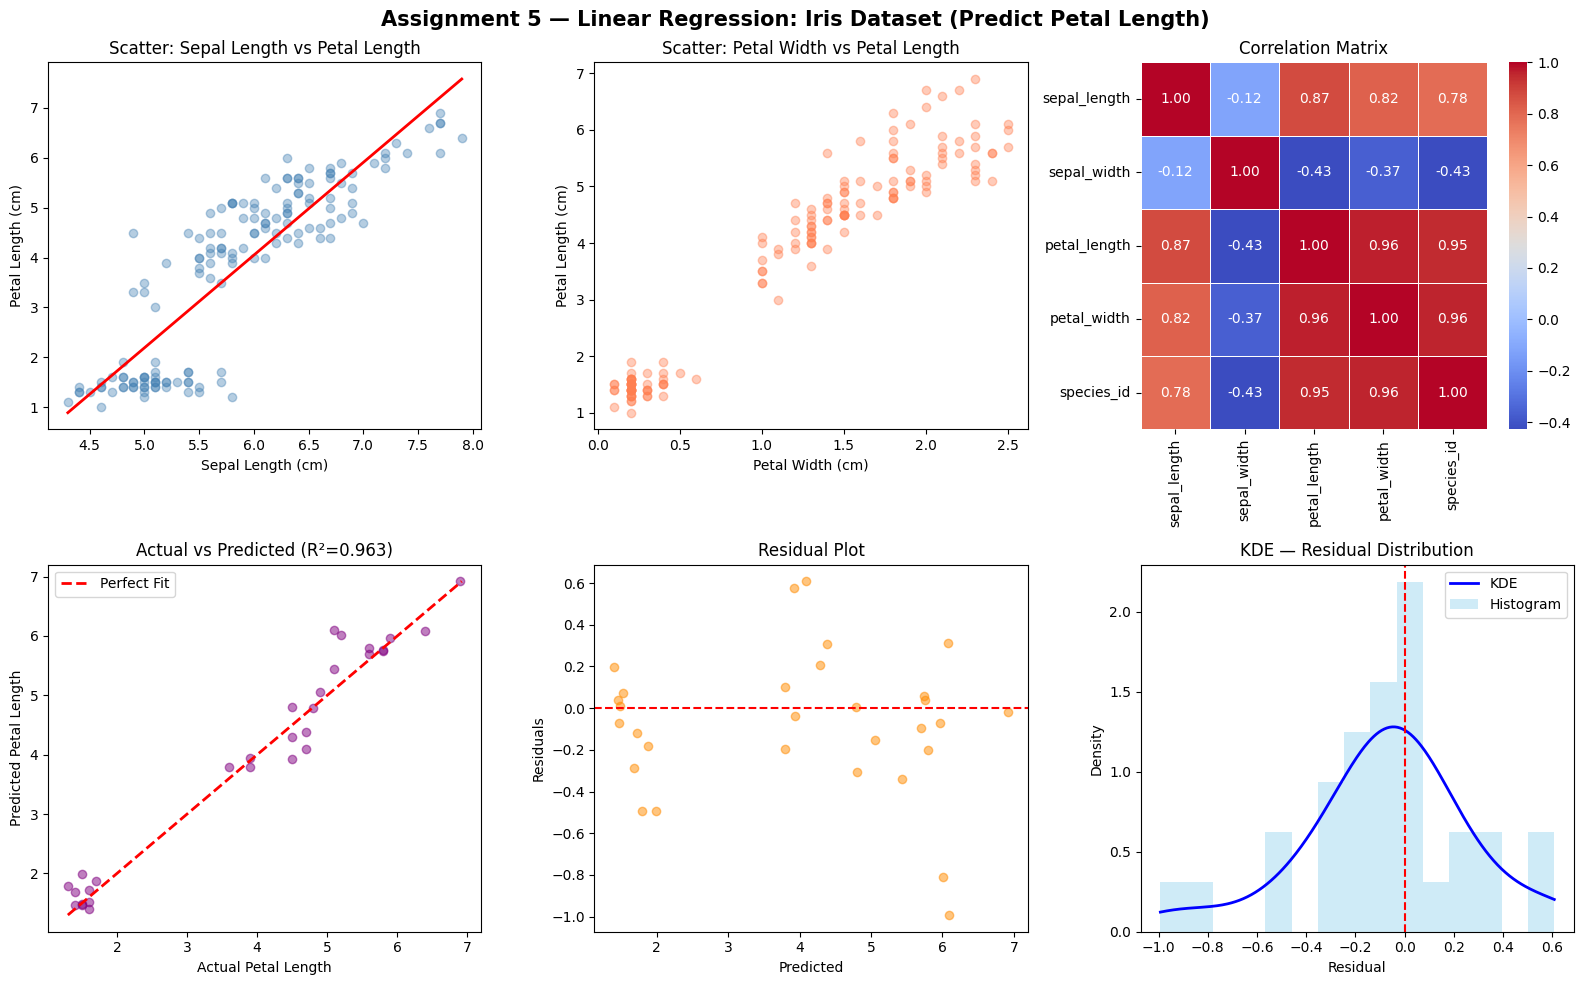

In [6]:
!pip install numpy pandas matplotlib seaborn scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width',
                                       'petal_length', 'petal_width'])
df['species_id'] = iris.target
print(f"📦 Iris Dataset loaded: {df.shape}")

print("\n🔹 Dataset shape:", df.shape)
print("\n🔹 Descriptive Stats:\n", df.describe().round(3))

print("\n🔹 Correlation with petal_length:\n",
      df.corr()['petal_length'].sort_values(ascending=False).round(3))

X = df.drop('petal_length', axis=1)
y = df['petal_length']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"  MAE  = {mae:.4f}")
print(f"  MSE  = {mse:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\n🔹 Coefficients:\n", coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Assignment 5 — Linear Regression: Iris Dataset (Predict Petal Length)', fontsize=15, fontweight='bold')

axes[0,0].scatter(df['sepal_length'], df['petal_length'], alpha=0.4, color='steelblue')
m, b = np.polyfit(df['sepal_length'], df['petal_length'], 1)
xr = np.linspace(df['sepal_length'].min(), df['sepal_length'].max(), 100)
axes[0,0].plot(xr, m*xr+b, 'r-', linewidth=2)
axes[0,0].set_title('Scatter: Sepal Length vs Petal Length')
axes[0,0].set_xlabel('Sepal Length (cm)'); axes[0,0].set_ylabel('Petal Length (cm)')

axes[0,1].scatter(df['petal_width'], df['petal_length'], alpha=0.4, color='coral')
axes[0,1].set_title('Scatter: Petal Width vs Petal Length')
axes[0,1].set_xlabel('Petal Width (cm)'); axes[0,1].set_ylabel('Petal Length (cm)')

corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,2], linewidths=0.5)
axes[0,2].set_title('Correlation Matrix')

axes[1,0].scatter(y_test, y_pred, alpha=0.5, color='purple')
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
axes[1,0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
axes[1,0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[1,0].set_xlabel('Actual Petal Length'); axes[1,0].set_ylabel('Predicted Petal Length')
axes[1,0].legend()

residuals = y_test - y_pred
axes[1,1].scatter(y_pred, residuals, alpha=0.5, color='darkorange')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Residual Plot')
axes[1,1].set_xlabel('Predicted'); axes[1,1].set_ylabel('Residuals')

axes[1,2].set_title('KDE — Residual Distribution')
from scipy.stats import gaussian_kde
kde_vals = gaussian_kde(residuals)
x_res = np.linspace(residuals.min(), residuals.max(), 300)
axes[1,2].plot(x_res, kde_vals(x_res), 'b-', linewidth=2, label='KDE')
axes[1,2].hist(residuals, bins=15, density=True, alpha=0.4, color='skyblue', label='Histogram')
axes[1,2].axvline(0, color='red', linestyle='--')
axes[1,2].set_xlabel('Residual'); axes[1,2].set_ylabel('Density')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('assignment5_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Accuracy: 0.9211  (92.11%)

📊 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38


  Silhouette Score (k=3): 0.6448


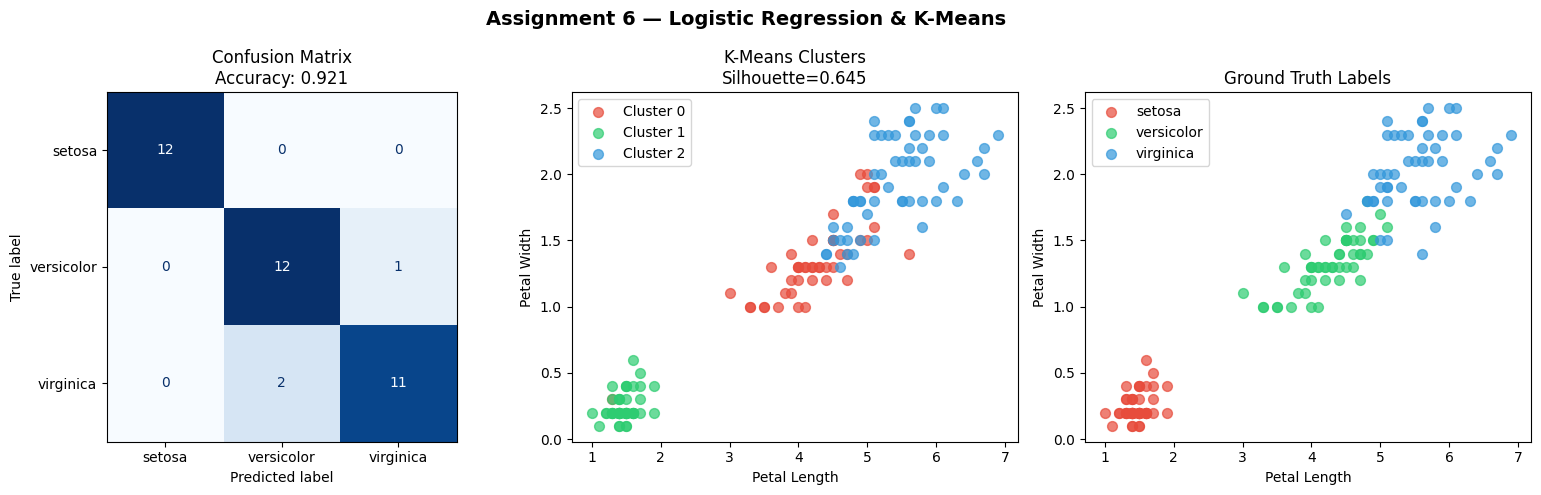

In [7]:
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark scikit-learn pandas numpy matplotlib seaborn --quiet
!apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator



iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=200, multi_class='multinomial', random_state=42)
log_reg.fit(X_train_sc, y_train)
y_pred = log_reg.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
print(f"\n  Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))



spark = SparkSession.builder \
    .appName("KMeansIRIS") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df_pd = pd.DataFrame(X, columns=['sepal_length','sepal_width','petal_length','petal_width'])
df_pd['true_label'] = y
sdf = spark.createDataFrame(df_pd)

assembler = VectorAssembler(
    inputCols=['sepal_length','sepal_width','petal_length','petal_width'],
    outputCol='features')
sdf_assembled = assembler.transform(sdf)

spark_scaler = SparkScaler(inputCol='features', outputCol='scaled_features')
scaler_model = spark_scaler.fit(sdf_assembled)
sdf_scaled   = scaler_model.transform(sdf_assembled)

kmeans = KMeans(featuresCol='scaled_features', k=3, seed=42, maxIter=100)
km_model = kmeans.fit(sdf_scaled)
predictions = km_model.transform(sdf_scaled)

evaluator = ClusteringEvaluator(featuresCol='scaled_features')
silhouette = evaluator.evaluate(predictions)
print(f"\n  Silhouette Score (k=3): {silhouette:.4f}")

pred_pd = predictions.select('sepal_length','sepal_width','petal_length',
                               'petal_width','true_label','prediction').toPandas()
spark.stop()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Assignment 6 — Logistic Regression & K-Means', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc:.3f}')

scatter_colors = ['#e74c3c','#2ecc71','#3498db']
for cluster in range(3):
    mask = pred_pd['prediction'] == cluster
    axes[1].scatter(pred_pd.loc[mask,'petal_length'],
                    pred_pd.loc[mask,'petal_width'],
                    c=scatter_colors[cluster], label=f'Cluster {cluster}', alpha=0.7, s=50)
axes[1].set_title(f'K-Means Clusters\nSilhouette={silhouette:.3f}')
axes[1].set_xlabel('Petal Length'); axes[1].set_ylabel('Petal Width')
axes[1].legend()

true_colors = ['#e74c3c','#2ecc71','#3498db']
for label, name in enumerate(target_names):
    mask = pred_pd['true_label'] == label
    axes[2].scatter(pred_pd.loc[mask,'petal_length'],
                    pred_pd.loc[mask,'petal_width'],
                    c=true_colors[label], label=name, alpha=0.7, s=50)
axes[2].set_title('Ground Truth Labels')
axes[2].set_xlabel('Petal Length'); axes[2].set_ylabel('Petal Width')
axes[2].legend()

plt.tight_layout()
plt.savefig('assignment6_logistic_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark --quiet
!apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]


from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import re

conf = SparkConf().setAppName("RDD_Demo").setMaster("local[*]")
sc   = SparkContext(conf=conf)
sc.setLogLevel("ERROR")


nums_rdd   = sc.parallelize([3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5])
fruits_rdd = sc.parallelize(["apple","banana","cherry","apple","mango","banana","apple"])
print("  Numbers RDD:", nums_rdd.collect())
print("  Fruits RDD :", fruits_rdd.collect())


squared = nums_rdd.map(lambda x: x**2)
print("  map (x²)          :", squared.collect())

evens = nums_rdd.filter(lambda x: x % 2 == 0)
print("  filter (even)     :", evens.collect())

distinct_nums = nums_rdd.distinct()
print("  distinct          :", sorted(distinct_nums.collect()))

words_rdd = sc.parallelize(["Hello World", "Apache Spark", "Big Data"])
flat = words_rdd.flatMap(lambda s: s.split())
print("  flatMap (words)   :", flat.collect())

sorted_rdd = nums_rdd.sortBy(lambda x: x, ascending=False)
print("  sortBy (desc)     :", sorted_rdd.collect())

# union
rdd_a = sc.parallelize([1, 2, 3])
rdd_b = sc.parallelize([3, 4, 5])
print("  union             :", rdd_a.union(rdd_b).collect())
print("  intersection      :", rdd_a.intersection(rdd_b).collect())



sales = sc.parallelize([
    ("Electronics", 1500), ("Clothing", 800),  ("Electronics", 2200),
    ("Food", 400),         ("Clothing", 1200),  ("Food", 600),
    ("Electronics", 900),  ("Clothing", 300),
])

total_by_dept = sales.reduceByKey(lambda a, b: a + b)
print("  reduceByKey (total sales):")
for dept, total in sorted(total_by_dept.collect()):
    print(f"    {dept:15s}: ₹{total}")

fruit_counts = fruits_rdd.countByValue()
print("\n  countByValue (fruits):", dict(fruit_counts))

grouped = sales.groupByKey().mapValues(list)
print("\n  groupByKey (sales values):")
for dept, vals in sorted(grouped.collect()):
    print(f"    {dept:15s}: {vals}")

sorted_sales = total_by_dept.sortBy(lambda x: x[1], ascending=False)
print("\n  sortBy value (descending):", sorted_sales.collect())


print(f"  count()    : {nums_rdd.count()}")
print(f"  first()    : {nums_rdd.first()}")
print(f"  take(3)    : {nums_rdd.take(3)}")
print(f"  top(3)     : {nums_rdd.top(3)}")
print(f"  sum()      : {nums_rdd.sum()}")
print(f"  mean()     : {nums_rdd.mean():.4f}")
print(f"  max()      : {nums_rdd.max()}")
print(f"  min()      : {nums_rdd.min()}")
print(f"  reduce(+)  : {nums_rdd.reduce(lambda a,b: a+b)}")


text_data = [
    "Spark is fast and reliable",
    "Spark is easy to use and fast",
    "Big data processing with Spark",
    "RDD transformations and actions in Spark"
]
text_rdd = sc.parallelize(text_data)

word_count = (
    text_rdd
    .flatMap(lambda line: line.lower().split())
    .map(lambda word: (word, 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[1], ascending=False)
)
print("  Word Counts (top 10):")
for word, count in word_count.take(10):
    print(f"    {word:20s}: {count}")

print("\n" + "="*55)
print("6. Persist & Cache")
print("="*55)
cached = total_by_dept.cache()
print("  RDD cached. Count:", cached.count())
print("  Accessing again (from cache):", cached.collect())

sc.stop()

  Numbers RDD: [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]
  Fruits RDD : ['apple', 'banana', 'cherry', 'apple', 'mango', 'banana', 'apple']
  map (x²)          : [9, 1, 16, 1, 25, 81, 4, 36, 25, 9, 25]
  filter (even)     : [4, 2, 6]
  distinct          : [1, 2, 3, 4, 5, 6, 9]
  flatMap (words)   : ['Hello', 'World', 'Apache', 'Spark', 'Big', 'Data']
  sortBy (desc)     : [9, 6, 5, 5, 5, 4, 3, 3, 2, 1, 1]
  union             : [1, 2, 3, 3, 4, 5]
  intersection      : [3]
  reduceByKey (total sales):
    Clothing       : ₹2300
    Electronics    : ₹4600
    Food           : ₹1000

  countByValue (fruits): {'apple': 3, 'banana': 2, 'cherry': 1, 'mango': 1}

  groupByKey (sales values):
    Clothing       : [800, 1200, 300]
    Electronics    : [1500, 2200, 900]
    Food           : [400, 600]

  sortBy value (descending): [('Electronics', 4600), ('Clothing', 2300), ('Food', 1000)]
  count()    : 11
  first()    : 3
  take(3)    : [3, 1, 4]
  top(3)     : [9, 6, 5]
  sum()      : 44
  mean()     :

In [9]:

!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark --quiet
!apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import re, math

conf = SparkConf().setAppName("MapReduce_Demo").setMaster("local[*]")
sc   = SparkContext(conf=conf)
sc.setLogLevel("ERROR")



documents = [
    "hadoop mapreduce processes large datasets in parallel",
    "spark provides in-memory processing for big data",
    "mapreduce divides data into map and reduce phases",
    "big data analytics requires distributed computing",
    "spark and hadoop are popular big data frameworks",
    "map phase transforms data reduce phase aggregates data",
]

text_rdd = sc.parallelize(documents)

word_count_rdd = (
    text_rdd
    .flatMap(lambda line: re.findall(r'\b\w+\b', line.lower()))   # MAP
    .map(lambda word: (word, 1))                                    # (key, value)
    .reduceByKey(lambda a, b: a + b)                               # REDUCE
    .sortBy(lambda x: x[1], ascending=False)
)

print("\n  Top 15 words:")
print(f"  {'Word':<20} {'Count':>5}")
print(f"  {'-'*25}")
for word, cnt in word_count_rdd.take(15):
    print(f"  {word:<20} {cnt:>5}")


transactions = [
    ("Electronics", 1500), ("Clothing", 800),  ("Electronics", 2200),
    ("Food", 400),         ("Clothing", 1200),  ("Food", 600),
    ("Electronics", 900),  ("Clothing", 300),   ("Food", 350),
    ("Electronics", 3200), ("Clothing", 750),   ("Food", 820),
    ("Books", 250),        ("Books", 380),       ("Books", 120),
]

sales_rdd = sc.parallelize(transactions)


def reduce_stats(a, b):
    return (a[0]+b[0], a[1]+b[1], max(a[2], b[2]))

sales_stats = (
    sales_rdd
    .map(lambda x: (x[0], (x[1], 1, x[1])))           # MAP: (cat, (amt, 1, amt))
    .reduceByKey(reduce_stats)                           # REDUCE: aggregate
    .map(lambda x: (x[0], x[1][0], x[1][1],            # FORMAT output
                    round(x[1][0]/x[1][1], 2), x[1][2]))
    .sortBy(lambda x: x[1], ascending=False)
)

print(f"\n  {'Category':<15} {'Total':>8} {'Count':>6} {'Average':>9} {'Max':>7}")
print(f"  {'-'*47}")
for cat, total, cnt, avg, mx in sales_stats.collect():
    print(f"  {cat:<15} {total:>8} {cnt:>6} {avg:>9} {mx:>7}")


log_lines = [
    "2024-01-15 10:23:01 ERROR Database connection failed",
    "2024-01-15 10:23:02 INFO  Server started on port 8080",
    "2024-01-15 10:23:03 WARN  Memory usage above 80%",
    "2024-01-15 10:23:04 INFO  Request received GET /api/users",
    "2024-01-15 10:23:05 ERROR NullPointerException in UserService",
    "2024-01-15 10:23:06 DEBUG Processing user authentication",
    "2024-01-15 10:23:07 INFO  Response sent 200 OK",
    "2024-01-15 10:23:08 WARN  Slow query detected (2.3s)",
    "2024-01-15 10:23:09 ERROR Timeout connecting to cache",
    "2024-01-15 10:23:10 INFO  User logged in: user123",
    "2024-01-15 10:23:11 DEBUG Cache miss for key user_456",
    "2024-01-15 10:23:12 INFO  Scheduled job started",
    "2024-01-15 10:23:13 WARN  API rate limit approaching",
    "2024-01-15 10:23:14 ERROR Disk space critically low",
]

log_rdd = sc.parallelize(log_lines)

log_levels = (
    log_rdd
    .map(lambda line: (line.split()[2].strip(), 1))    # MAP: extract level
    .reduceByKey(lambda a, b: a + b)                    # REDUCE: count
    .sortBy(lambda x: x[1], ascending=False)
)

total_logs = len(log_lines)
print(f"\n  {'Level':<10} {'Count':>6} {'Percentage':>12}")
print(f"  {'-'*30}")
for level, cnt in log_levels.collect():
    pct = cnt / total_logs * 100
    print(f"  {level:<10} {cnt:>6} {pct:>10.1f}%")


student_records = [
    ("Alice",   "Math",    85), ("Bob",   "Math",    72), ("Carol", "Math",    91),
    ("Dave",    "Math",    60), ("Eve",   "Math",    78), ("Alice", "Science", 88),
    ("Bob",     "Science", 65), ("Carol", "Science", 79), ("Dave",  "Science", 55),
    ("Eve",     "Science", 92), ("Alice", "English", 76), ("Bob",   "English", 83),
    ("Carol",   "English", 68), ("Dave",  "English", 74), ("Eve",   "English", 89),
]

student_rdd = sc.parallelize(student_records)

subject_stats = (
    student_rdd
    .map(lambda x: (x[1], (x[2], 1, x[2], 1 if x[2] >= 70 else 0)))   # MAP
    .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1],
                                max(a[2],b[2]), a[3]+b[3]))              # REDUCE
    .map(lambda x: (x[0],
                    round(x[1][0]/x[1][1], 2),   # avg
                    x[1][2],                      # max
                    x[1][1],                      # count
                    round(x[1][3]/x[1][1]*100,1))) # pass%
    .sortBy(lambda x: x[1], ascending=False)
)

print(f"\n  {'Subject':<10} {'Avg':>6} {'Max':>5} {'Students':>9} {'Pass%':>7}")
print(f"  {'-'*40}")
for subj, avg, mx, cnt, pp in subject_stats.collect():
    print(f"  {subj:<10} {avg:>6} {mx:>5} {cnt:>9} {pp:>6}%")


docs = [
    (1, "spark hadoop mapreduce big data"),
    (2, "hadoop distributed file system hdfs"),
    (3, "spark streaming real time data processing"),
    (4, "mapreduce programming model hadoop"),
    (5, "big data analytics spark sql"),
]

docs_rdd = sc.parallelize(docs)

inverted_index = (
    docs_rdd
    .flatMap(lambda x: [(word, x[0]) for word in x[1].split()])   # MAP
    .groupByKey()                                                    # SHUFFLE
    .mapValues(lambda doc_ids: sorted(set(doc_ids)))                # REDUCE
    .sortByKey()
)

print(f"\n  {'Word':<15} {'Documents'}")
print(f"  {'-'*35}")
for word, doc_list in inverted_index.collect():
    print(f"  {word:<15} {doc_list}")

sc.stop()


  Top 15 words:
  Word                 Count
  -------------------------
  data                     6
  big                      3
  hadoop                   2
  map                      2
  and                      2
  phase                    2
  mapreduce                2
  in                       2
  spark                    2
  reduce                   2
  processes                1
  large                    1
  datasets                 1
  parallel                 1
  memory                   1

  Category           Total  Count   Average     Max
  -----------------------------------------------
  Electronics         7800      4    1950.0    3200
  Clothing            3050      4     762.5    1200
  Food                2170      4     542.5     820
  Books                750      3     250.0     380

  Level       Count   Percentage
  ------------------------------
  INFO            5       35.7%
  ERROR           4       28.6%
  WARN            3       21.4%
  DEBUG          

In [12]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [13]:
!git remote add origin https://github.com/Mohinish-K053/BDA.git

In [14]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	assignment1_eda.png
	assignment2_distributions.png
	assignment3_hypothesis.png
	assignment4_iris_wrangling.png
	assignment5_linear_regression.png
	assignment6_logistic_kmeans.png
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
